In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 2s 0us/step


In [3]:
train_images.shape

(60000, 28, 28)

In [4]:
train_images[0,23,23]

194

In [5]:
train_labels[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover','Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

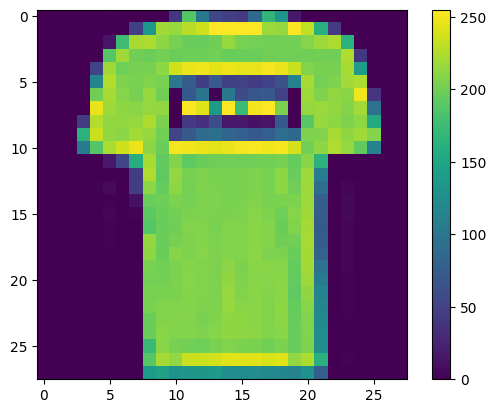

In [7]:
plt.figure()
plt.imshow(train_images[1])
plt.colorbar()
plt.grid(False)
plt.show()

In [8]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [10]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')])

In [12]:
model.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

In [13]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4952 - accuracy: 0.8260
Epoch 2/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3761 - accuracy: 0.8656
Epoch 3/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3356 - accuracy: 0.8796
Epoch 4/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3146 - accuracy: 0.8845
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2934 - accuracy: 0.8921
Epoch 6/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2814 - accuracy: 0.8967
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2671 - accuracy: 0.9008
Epoch 8/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2573 - accuracy: 0.9038
Epoch 9/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2474 - accuracy: 0.9069
Epoch 10/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.238

In [15]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=1)
print("Test Accuracy: ", test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.3300 - accuracy: 0.8847
Test Accuracy:  0.8847000002861023


In [20]:
predictions = model.predict(test_images)
print(np.argmax(predictions[0]))

313/313 [==============================] - 1s 2ms/step
9


<function matplotlib.pyplot.show(close=None, block=None)>

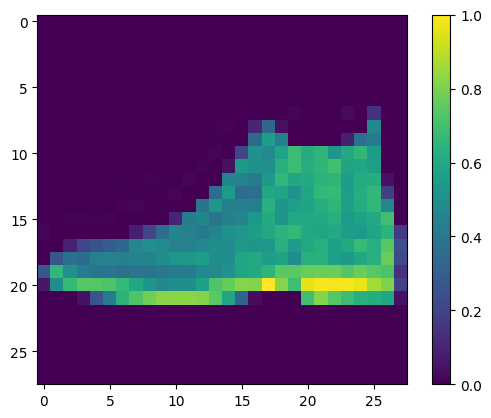

In [22]:
plt.figure()
plt.imshow(test_images[0])
plt.colorbar()
plt.grid(False)
plt.show

Pick a number:  12


1/1 [==============================] - 0s 16ms/step


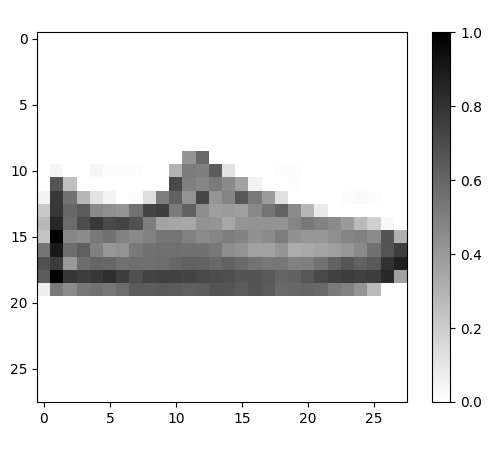

In [28]:
COLOR = 'white'
plt.rcParams['text.color'] = COLOR
plt.rcParams['axes.labelcolor'] = COLOR

def predict(model, image, correct_label):
    class_names = ['T-shirt/top', 'Trouser', 'Pullover','Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
    prediction = model.predict(np.array([image]))
    predicted_class = class_names[np.argmax(prediction)]
    show_image(image, class_names[correct_label], predicted_class)

def show_image(img, label, guess):
    plt.figure()
    plt.imshow(img, cmap=plt.cm.binary)
    plt.title("Expected: " + label)
    plt.xlabel("Guess: " + guess)
    plt.colorbar()
    plt.grid(False)
    plt.show()

def get_number():
    while True:
        num = input("Pick a number: ")
        if num.isdigit():
            num = int(num)
            if 0 <= num <= 1000:
                return int(num)
        else:
            print("Try Again")
num = get_number()
image = test_images[num]
label = test_labels[num]
predict(model, image, label)